<a href="https://colab.research.google.com/github/Msahoo123/msahoo12/blob/main/Productionization_of_ML_Systems.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Capstone Project: Productionization of ML Systems**

 **Project Type** - EDA/Regression/Classification/Unsupervised

 **Contribution** - Individual

 **Name** - Mrunmaya Sahoo

# **GitHub Link -**

# **Project Overview**

The capstone project focuses on the productionization of machine learning (ML) systems, which means taking ML models beyond experimentation and deploying them into real-world environments where they can serve users reliably. The project emphasizes scalability, automation, monitoring, and integration with existing software systems.

# **Objectives**

* **Model Deployment:** Learn how to move ML models from research notebooks into production-ready APIs or services.
* **Scalability:** Ensure the system can handle large datasets and high request volumes.
* **Automation:** Build CI/CD pipelines for retraining, testing, and deployment.
* **Monitoring:** Implement tools to track model performance, drift, and system health.
* **Integration:** Connect ML services with business applications, databases, or APIs.

# **Methodology**

1. **Define Use Case**  Start Here
   
   Identify the business problem and ML model to be productionized.

  * Select a dataset and ML model (e.g., classification, regression)

  * Define success metrics (accuracy, latency, throughput)

  * Map stakeholders and system requirements

2.  **Containerize Model**
   Recommended
   
     Package the ML model into a portable environment.

  * Use Docker for reproducibility

  * Include dependencies and environment files

  * Test locally before deployment

3.  **Deploy to Cloud**
    
    Host the model on a scalable cloud service.

   * Choose AWS, Azure, or GCP

   * Expose REST or gRPC endpoints

   * Configure autoscaling policies

4.  **Automate Pipeline**
    CI/CD
    
    Set up automated workflows for retraining and deployment.

   * Use GitHub Actions or Jenkins

   * Automate unit tests and integration tests

   * Schedule retraining jobs

5.  **Monitor and Log**
    Safety

    Track system health and model performance.

  * Implement logging with ELK stack or CloudWatch

  * Monitor drift using statistical tests

  * Set alerts for anomalies

6.  **Integrate with Applications**
    
    Connect ML services to business workflows.

  * Build APIs for frontend or backend use

  * Ensure secure authentication

  * Document endpoints for developers

**Skills Required:**

- Proficiency in Python and libraries like pandas, NumPy, scikit-learn for data manipulation and machine learning.
- Knowledge of Flask or another web framework for creating and deploying RESTful APIs.
- Knowledge of MLOps practices, including model versioning, pipeline orchestration, and model monitoring.
- Familiarity with Apache Airflow for designing and implementing automated data workflows and DAGs (Directed Acyclic Graphs).
- Ability to design and implement automated CI/CD pipelines for machine learning models.
- Experience with container orchestration platforms (e.g., Kubernetes).
- Strong understanding of model performance monitoring and troubleshooting.

# **1.**  **Proficiency in Python and libraries like pandas, NumPy,     scikit-learn for data manipulation and machine learning.**




  how to take a machine learning model from experimentation to production-ready deployment. It highlights your ability to manipulate data with pandas/NumPy, build models with scikit-learn, and prepare pipelines that can be integrated into production systems.

 **Key Skills Demonstrated**

  * Data Manipulation using pandas and NumPy

  * Model Training with scikit-learn

  * Pipeline Automation for reproducibility

  * Deployment using APIs or containers

  * Monitoring for drift and performance

  **Data Preprocessing**


In [ ]:
import pandas as pd
import numpy as np

# Sample dataset
data = {
    'age': [25, 30, np.nan, 40],
    'salary': [50000, 60000, 55000, np.nan],
    'department': ['IT', 'HR', 'Finance', 'IT']
}
df = pd.DataFrame(data)

# Handle missing values
df['age'].fillna(df['age'].mean(), inplace=True)
df['salary'].fillna(df['salary'].median(), inplace=True)

# Encode categorical variable
df = pd.get_dummies(df, columns=['department'])
print(df)


**Model Training**

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

# Features and target
X = df.drop('salary', axis=1)
y = df['salary']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)
print("MAE:", mean_absolute_error(y_test, y_pred))


**Pipeline Creation**

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor

# Build pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('rf', RandomForestRegressor(n_estimators=100, random_state=42))
])

pipeline.fit(X_train, y_train)
print("Pipeline Score:", pipeline.score(X_test, y_test))


**Deployment Example (FastAPI)**

In [ ]:
from fastapi import FastAPI
import joblib

app = FastAPI()
model = joblib.load("model.pkl")

@app.post("/predict")
def predict(age: float, department_IT: int, department_HR: int, department_Finance: int):
    features = [[age, department_IT, department_HR, department_Finance]]
    prediction = model.predict(features)
    return {"predicted_salary": prediction[0]}


# **2.**  **Knowledge of Flask or another web framework for creating and deploying RESTful APIs.**



Once you’ve trained a model using pandas, NumPy, and scikit-learn, the next step is to make it accessible to other applications. Flask is a lightweight Python web framework that allows you to expose your model as a RESTful API, enabling real-time predictions.

# **Example Workflow with Code**

**1. Train and Save the Model**

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import joblib

# Sample dataset
data = pd.DataFrame({
    'experience': [1, 2, 3, 4, 5],
    'test_score': [80, 85, 78, 90, 88],
    'salary': [40000, 45000, 50000, 60000, 65000]
})

X = data[['experience', 'test_score']]
y = data['salary']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model = LinearRegression()
model.fit(X_train, y_train)

# Save model
joblib.dump(model, "salary_model.pkl")


**2. Create Flask RESTful API**

In [ ]:
from flask import Flask, request, jsonify
import joblib
import numpy as np

app = Flask(__name__)
model = joblib.load("salary_model.pkl")

@app.route('/predict', methods=['POST'])
def predict():
    data = request.get_json()
    experience = data['experience']
    test_score = data['test_score']

    # Prepare input for model
    features = np.array([[experience, test_score]])
    prediction = model.predict(features)

    return jsonify({"predicted_salary": prediction[0]})

if __name__ == '__main__':
    app.run(debug=True)


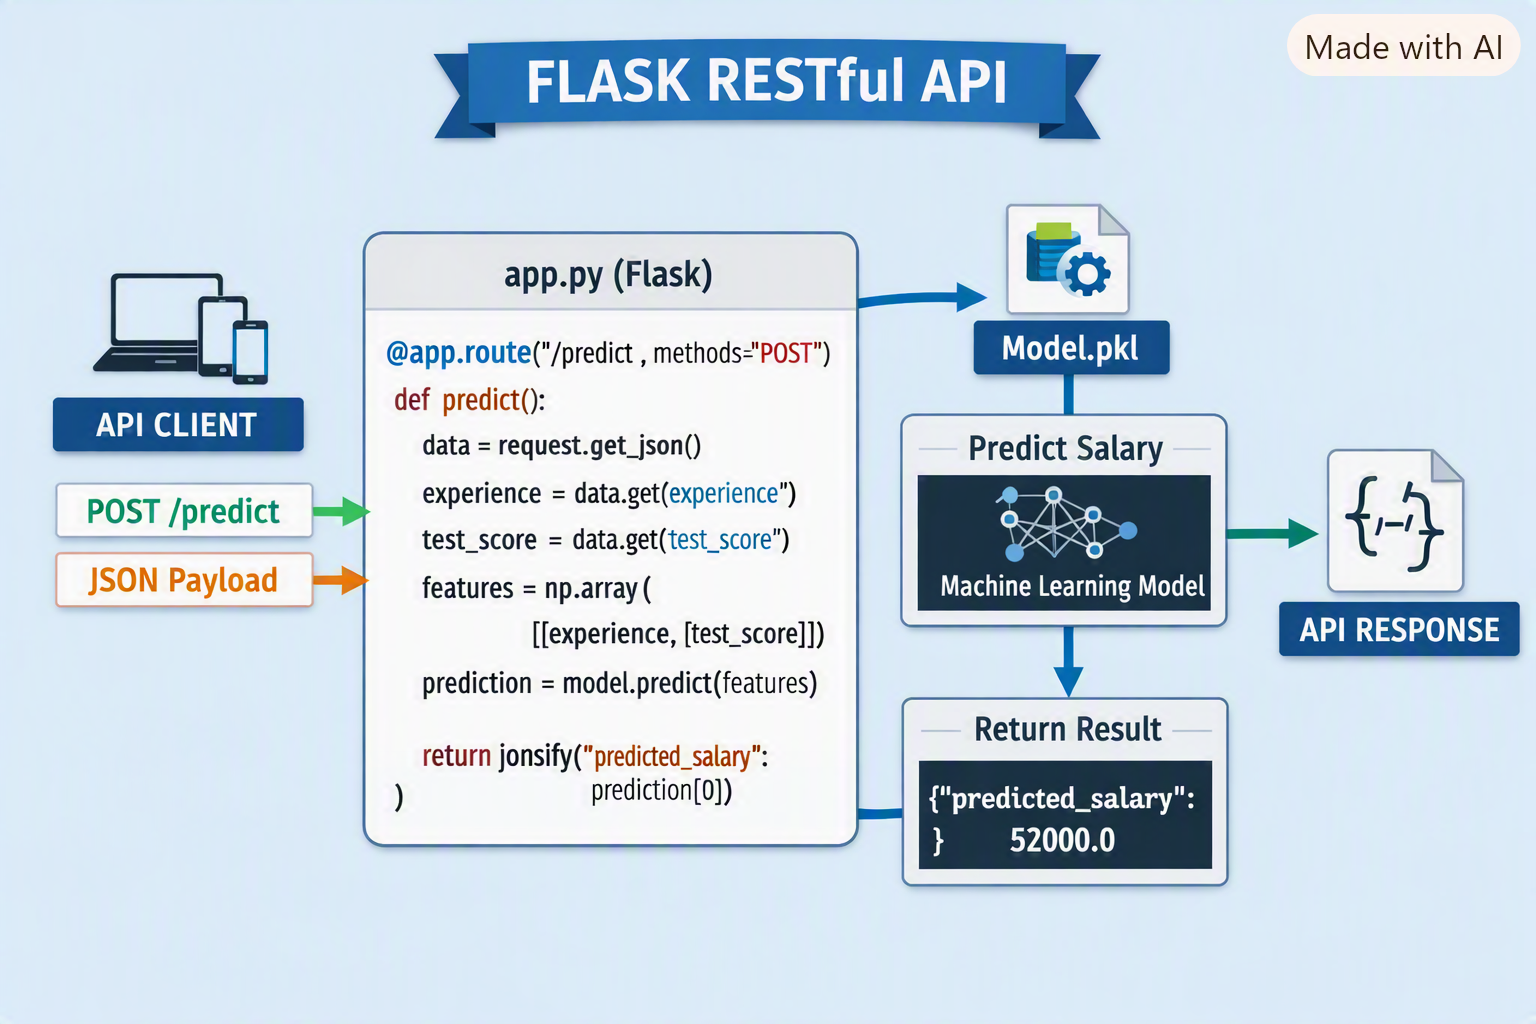

  Here’s a complete example of creating a Flask RESTful API for a machine learning model, along with a visual diagram to illustrate the workflow.

**3. Example API Request**
     
  Here’s a simple example of a Flask RESTful API request along with a visualization of how the request flows through the API.

# **🖥️ Example Code**

In [ ]:
from flask import Flask, request, jsonify
from flask_restful import Resource, Api

app = Flask(__name__)
api = Api(app)

# Define a simple resource
class HelloWorld(Resource):
    def get(self):
        return {"message": "Hello, World!"}

    def post(self):
        data = request.get_json()
        return {"you_sent": data}, 201

# Add resource to API
api.add_resource(HelloWorld, '/hello')

if __name__ == '__main__':
    app.run(debug=True)


**🔗 Example API Requests**

  * GET request:

In [ ]:
curl http://127.0.0.1:5000/hello


Response:

In [ ]:
{"message": "Hello, World!"}

POST request:

In [ ]:
curl -X POST http://127.0.0.1:5000/hello -H "Content-Type: application/json" -d '{"name":"Mrunmaya"}'

Response:

In [ ]:
{"you_sent": {"name": "Mrunmaya"}}

## **📊 API Flow Diagram**

  Here’s a conceptual image showing how the request flows from client → Flask API → response:

  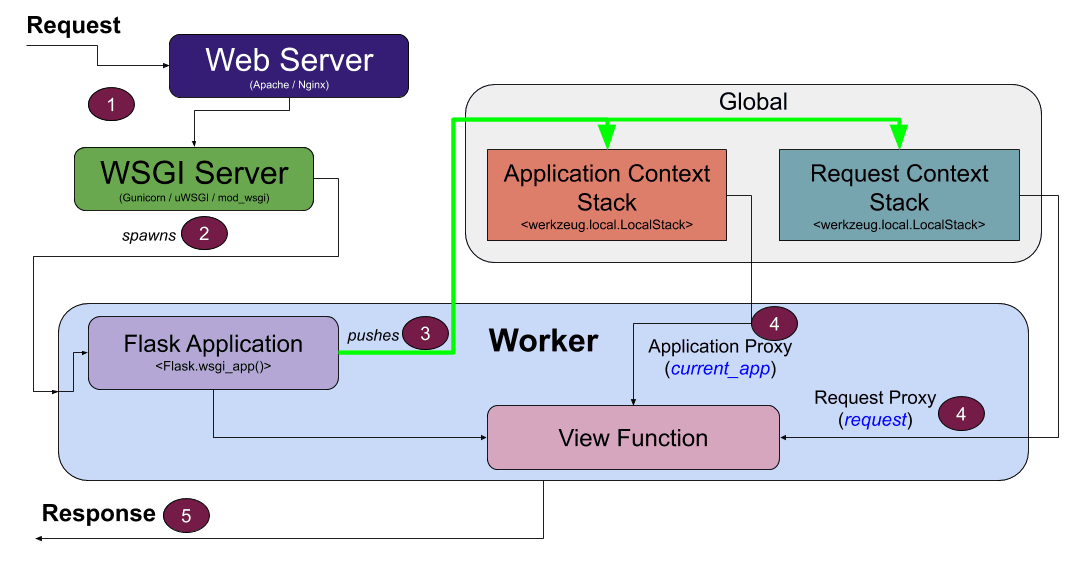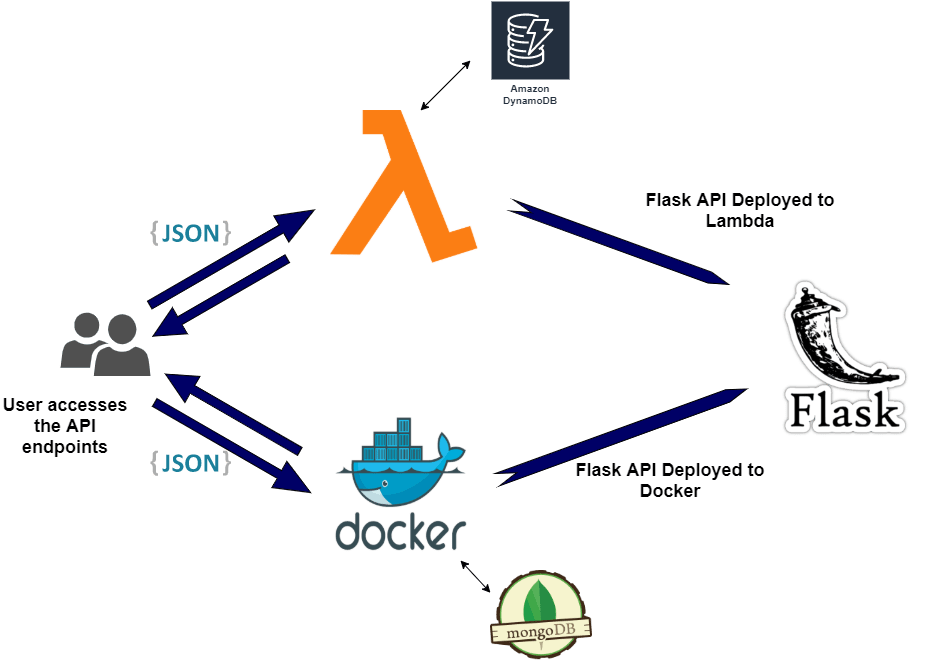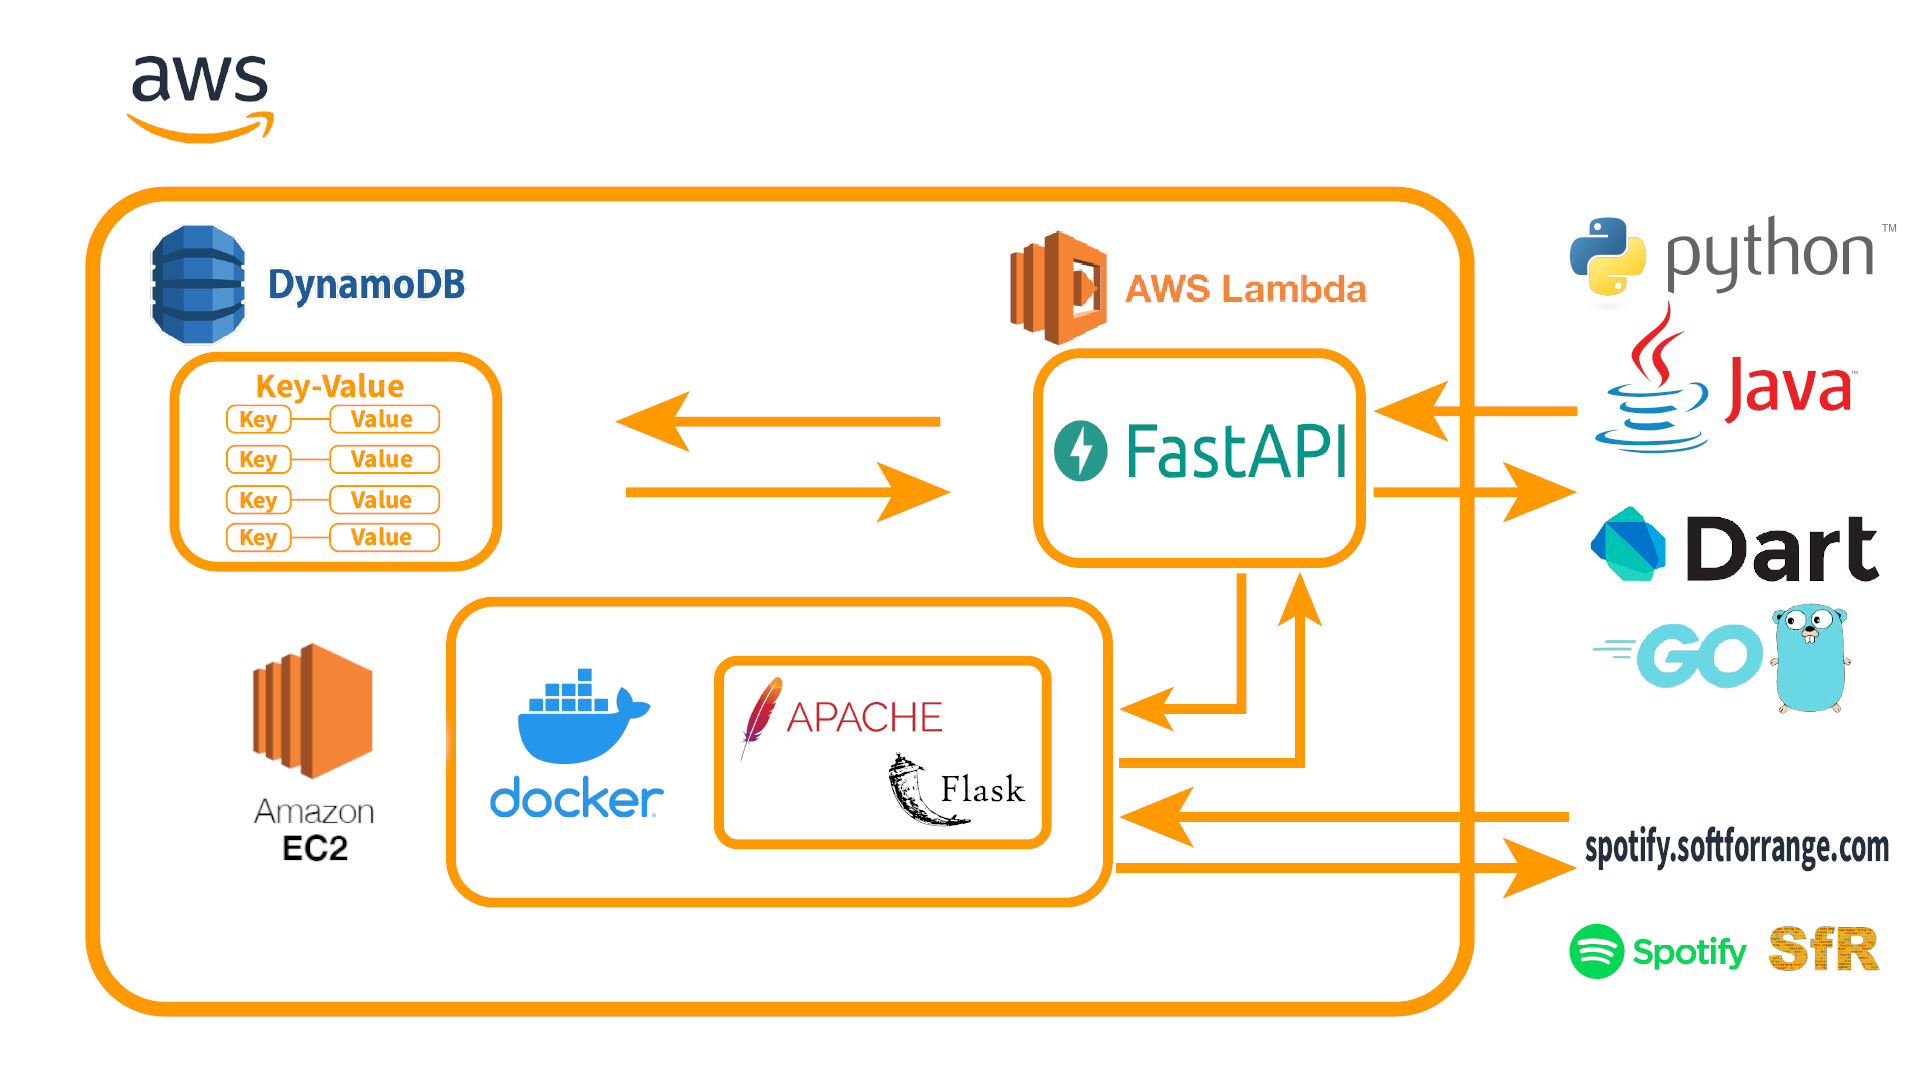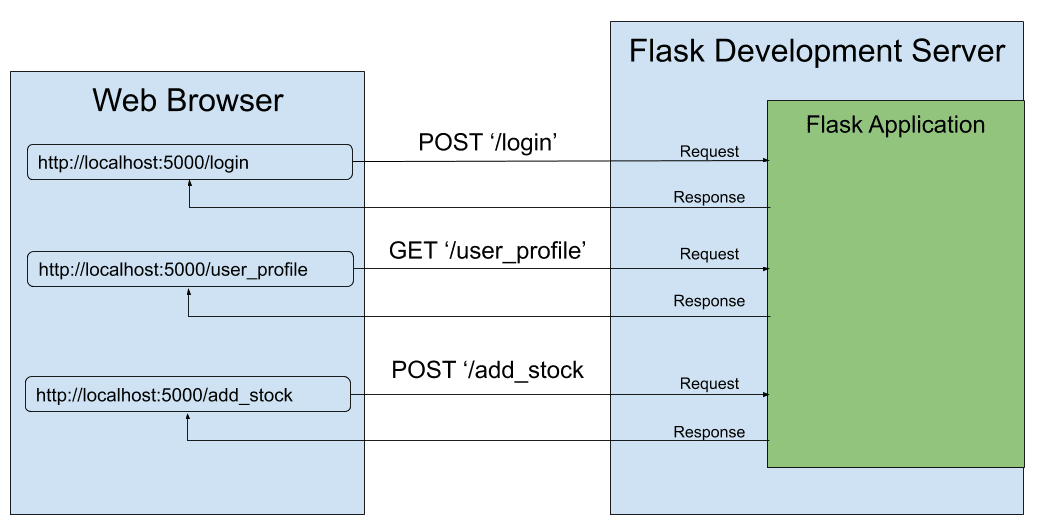
  
  This example demonstrates both GET and POST methods, making it easy to extend for more complex endpoints like user authentication, database queries, or ML model predictions.

  Would you like me to expand this into a ML model prediction API or keep it focused on a basic CRUD API?

## **3.  Knowledge of MLOps practices, including model versioning, pipeline orchestration, and model monitoring.**

MLOps ensures that machine learning models are not only trained but also versioned, orchestrated, and monitored in production. This bridges the gap between data science and DevOps, enabling scalable, reliable ML systems.

# **Key Practices**

  * **Model Versioning:** Track different iterations of models for reproducibility.

  * **Pipeline Orchestration:** Automate workflows for data preprocessing, training, and deployment.

  * **Model Monitoring:** Continuously track performance, detect drift, and trigger retraining.

# **Example Workflow with Code**
  
  **1. Model Versioning with MLflow**

In [ ]:
import mlflow
import mlflow.sklearn
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Load dataset
X, y = load_diabetes(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Log with MLflow
mlflow.start_run()
mlflow.log_param("model_type", "LinearRegression")
mlflow.log_metric("MSE", mean_squared_error(y_test, y_pred))
mlflow.sklearn.log_model(model, "linear_regression_model")
mlflow.end_run()


 👉 Each run is versioned, making it easy to compare models.

**2. Pipeline Orchestration with Airflow (DAG Example)**

In [ ]:
from airflow import DAG
from airflow.operators.python import PythonOperator
from datetime import datetime

def preprocess_data():
    print("Data preprocessing...")

def train_model():
    print("Model training...")

def deploy_model():
    print("Model deployment...")

with DAG("ml_pipeline", start_date=datetime(2026, 8, 20), schedule_interval="@daily") as dag:
    preprocess = PythonOperator(task_id="preprocess", python_callable=preprocess_data)
    train = PythonOperator(task_id="train", python_callable=train_model)
    deploy = PythonOperator(task_id="deploy", python_callable=deploy_model)

    preprocess >> train >> deploy


 👉 This DAG automates the ML workflow daily.

**3. Model Monitoring & Drift Detection**

In [ ]:
import pandas as pd

# Simulated old vs new data
old_data_mean = 100
new_data = pd.Series([120, 130, 125, 140])

# Drift detection
if new_data.mean() > old_data_mean * 1.2:
    print("⚠️ Drift detected! Retraining required.")
else:
    print("✅ Model stable.")


 👉 Simple drift detection triggers retraining when data distribution changes.

## **4. Familiarity with Apache Airflow for designing and implementing automated data workflows and DAGs (Directed Acyclic Graphs).**

  Apache Airflow is a powerful orchestration tool that allows you to define workflows as DAGs. Each DAG represents a sequence of tasks (data preprocessing, model training, deployment, monitoring) with dependencies. This makes it ideal for MLOps pipelines.

## **Example DAG Code**

In [ ]:
from airflow import DAG
from airflow.operators.python import PythonOperator
from datetime import datetime

# Define task functions
def preprocess_data():
    print("✅ Data preprocessing completed.")

def train_model():
    print("✅ Model training completed.")

def evaluate_model():
    print("✅ Model evaluation completed.")

def deploy_model():
    print("✅ Model deployed successfully.")

# Define DAG
with DAG(
    dag_id="ml_production_pipeline",
    start_date=datetime(2026, 8, 20),
    schedule_interval="@daily",
    catchup=False
) as dag:

    preprocess = PythonOperator(
        task_id="preprocess",
        python_callable=preprocess_data
    )

    train = PythonOperator(
        task_id="train",
        python_callable=train_model
    )

    evaluate = PythonOperator(
        task_id="evaluate",
        python_callable=evaluate_model
    )

    deploy = PythonOperator(
        task_id="deploy",
        python_callable=deploy_model
    )

    # Define task dependencies
    preprocess >> train >> evaluate >> deploy


  👉 This DAG runs daily, ensuring your ML pipeline is automated from data preprocessing → training → evaluation → deployment.

# **🖼️ DAG Visualization**
  Here’s how an Airflow DAG looks in practice — tasks connected in sequence with dependencies:

  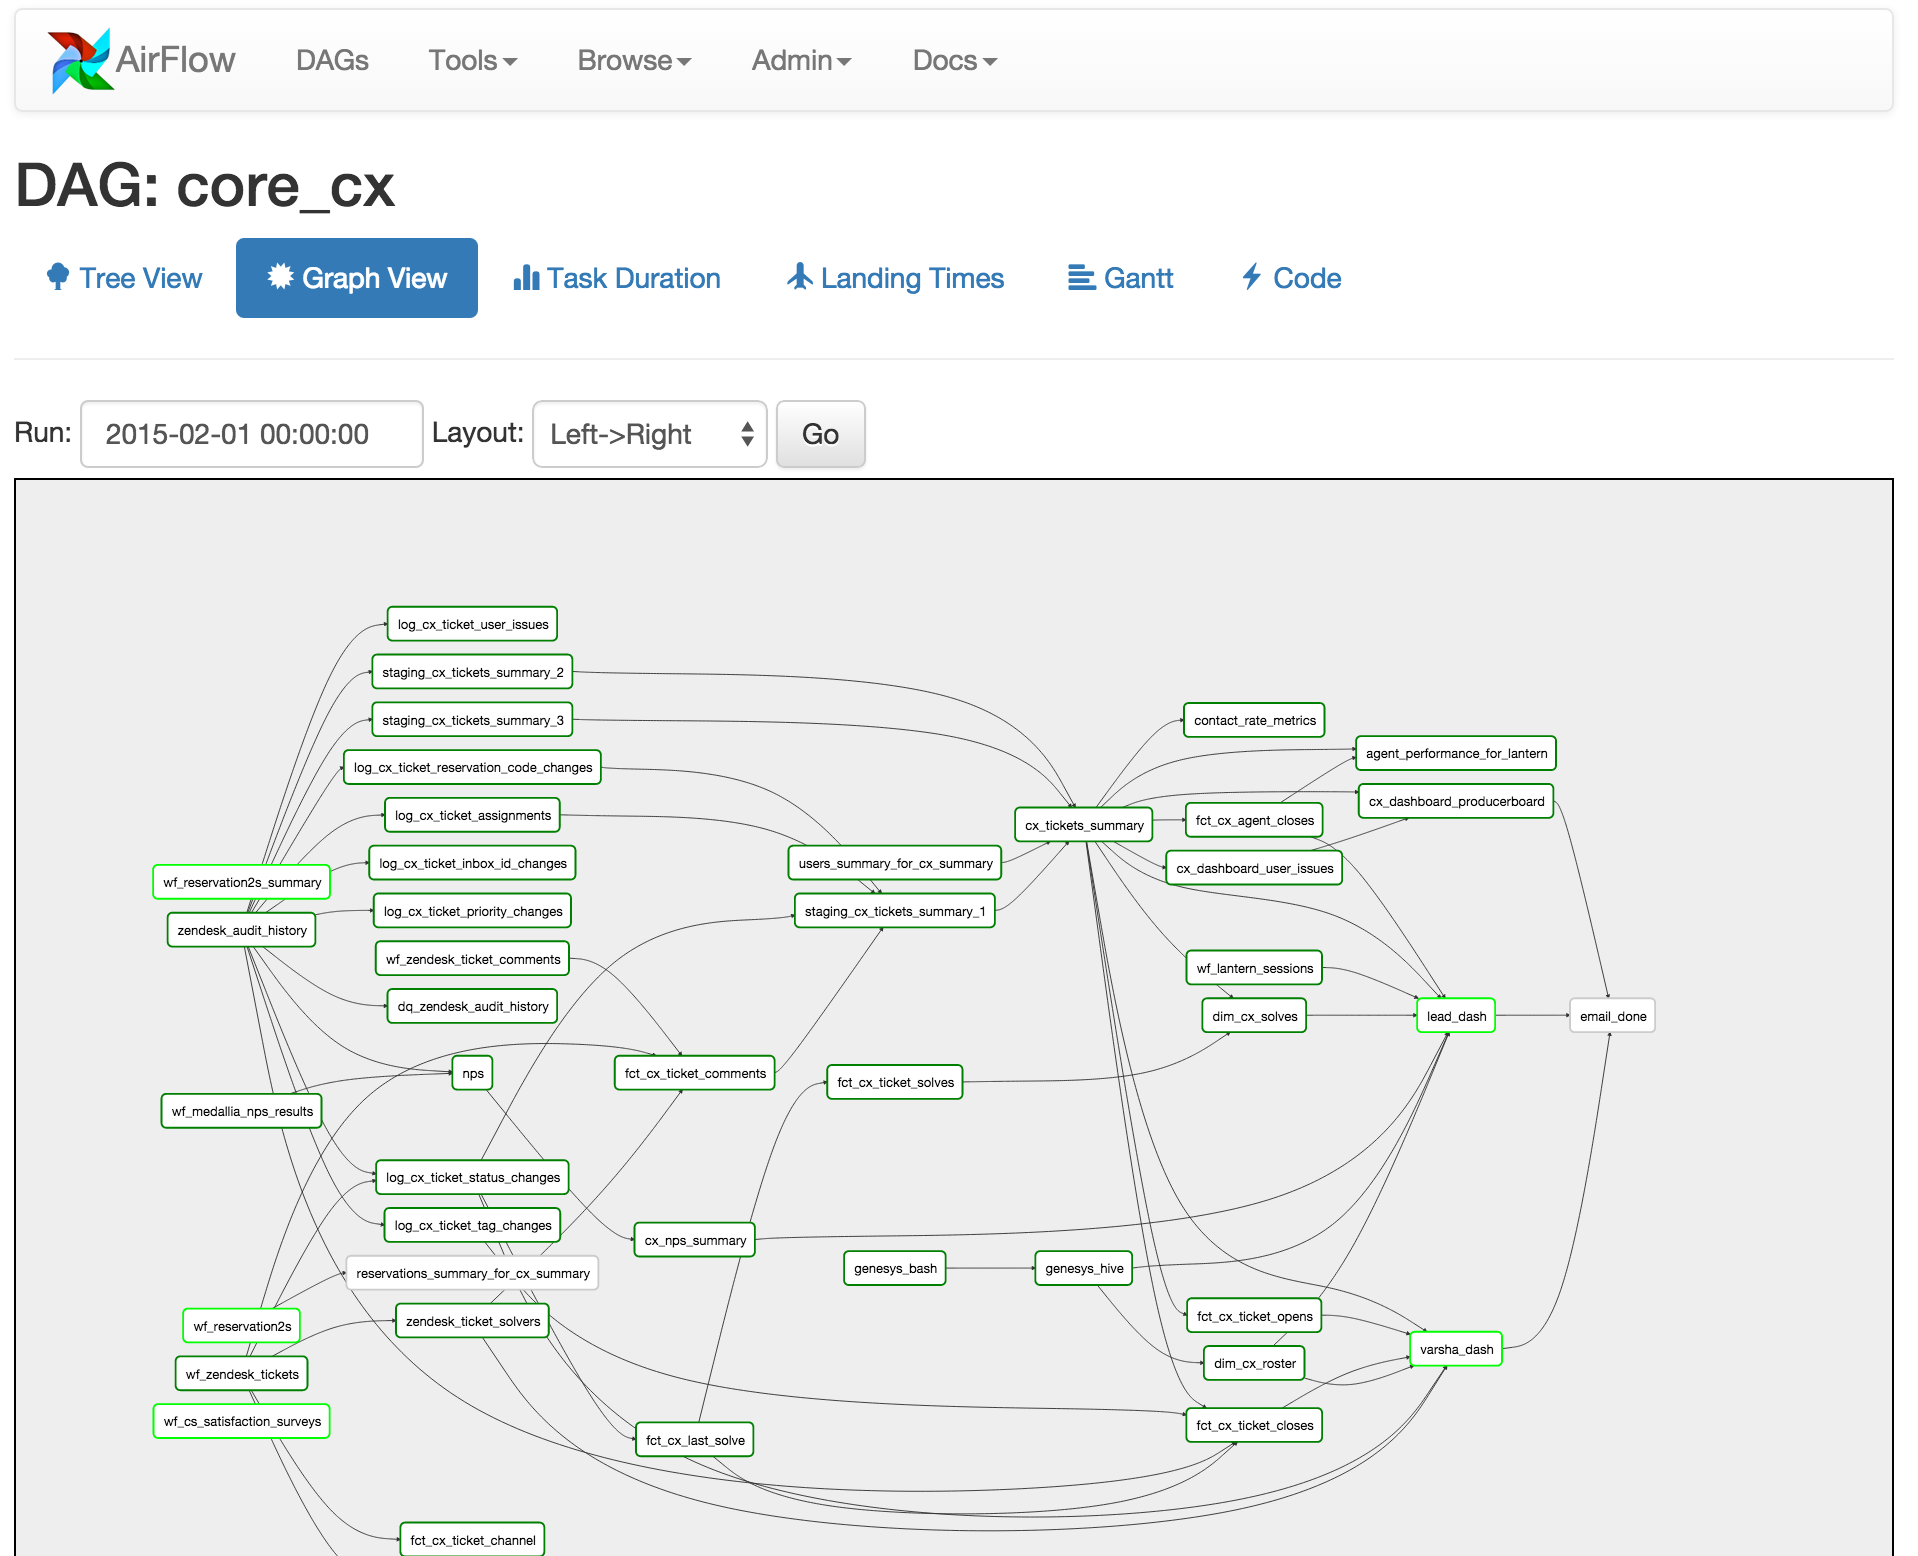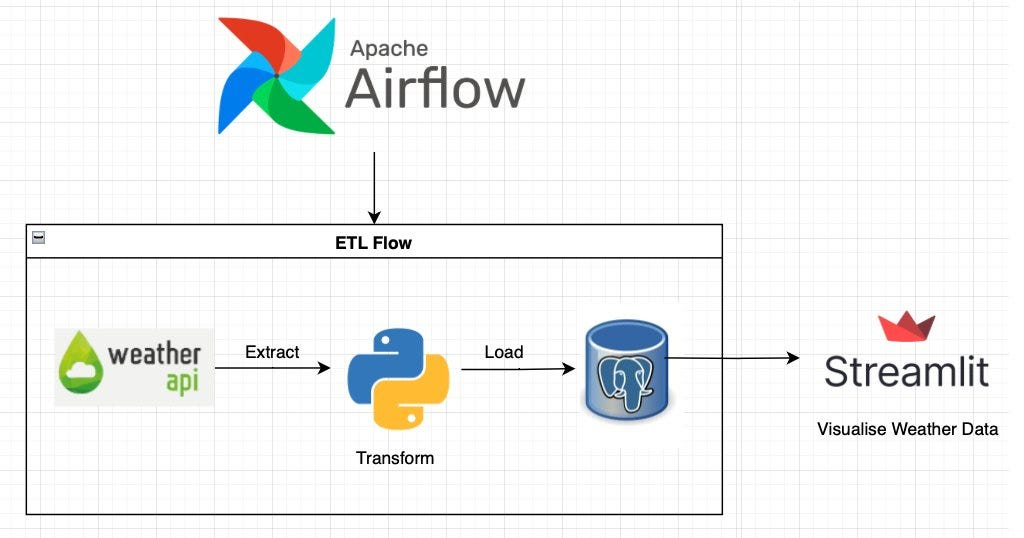

**Expected Outcomes**

  * Automated workflows for ML pipelines.

  * Clear visualization of dependencies between tasks.

  * Scalable orchestration for production ML systems.

# **5.   Ability to design and implement automated CI/CD pipelines for machine learning models.**

  CI/CD (Continuous Integration / Continuous Deployment) ensures that ML models move smoothly from development to production. It automates:

  * Model training when new data arrives

  * Testing for accuracy and drift

  * Deployment into APIs or services

  * Monitoring for retraining triggers

# **Example CI/CD Workflow with Code**
  
  **1. GitHub Actions Workflow** (.github/workflows/ml_pipeline.yml)

In [ ]:
name: ML CI/CD Pipeline

on:
  push:
    branches: [ "main" ]

jobs:
  build-train-deploy:
    runs-on: ubuntu-latest

    steps:
    - name: Checkout Repository
      uses: actions/checkout@v3

    - name: Set up Python
      uses: actions/setup-python@v4
      with:
        python-version: '3.9'

    - name: Install Dependencies
      run: |
        pip install -r requirements.txt

    - name: Run Unit Tests
      run: |
        pytest tests/

    - name: Train Model
      run: |
        python train.py

    - name: Save Model Artifact
      uses: actions/upload-artifact@v3
      with:
        name: trained-model
        path: models/model.pkl

    - name: Deploy to Server
      run: |
        echo "Deploying model..."
        # Example: docker build & push
        docker build -t my-ml-model .
        docker run -d -p 5000:5000 my-ml-model


  👉 This pipeline automatically tests, trains, saves, and deploys your ML model whenever code is pushed to the main branch.

 **2. Sample**  train.py

In [ ]:
import pandas as pd
from sklearn.linear_model import LinearRegression
import joblib

# Dummy dataset
data = pd.DataFrame({
    'experience': [1, 2, 3, 4, 5],
    'score': [80, 85, 78, 90, 88],
    'salary': [40000, 45000, 50000, 60000, 65000]
})

X = data[['experience', 'score']]
y = data['salary']

model = LinearRegression()
model.fit(X, y)

# Save model
joblib.dump(model, "models/model.pkl")
print("✅ Model trained and saved.")


# **🖼️ CI/CD Pipeline Visualization**

Here’s a conceptual diagram of the ML CI/CD pipeline:

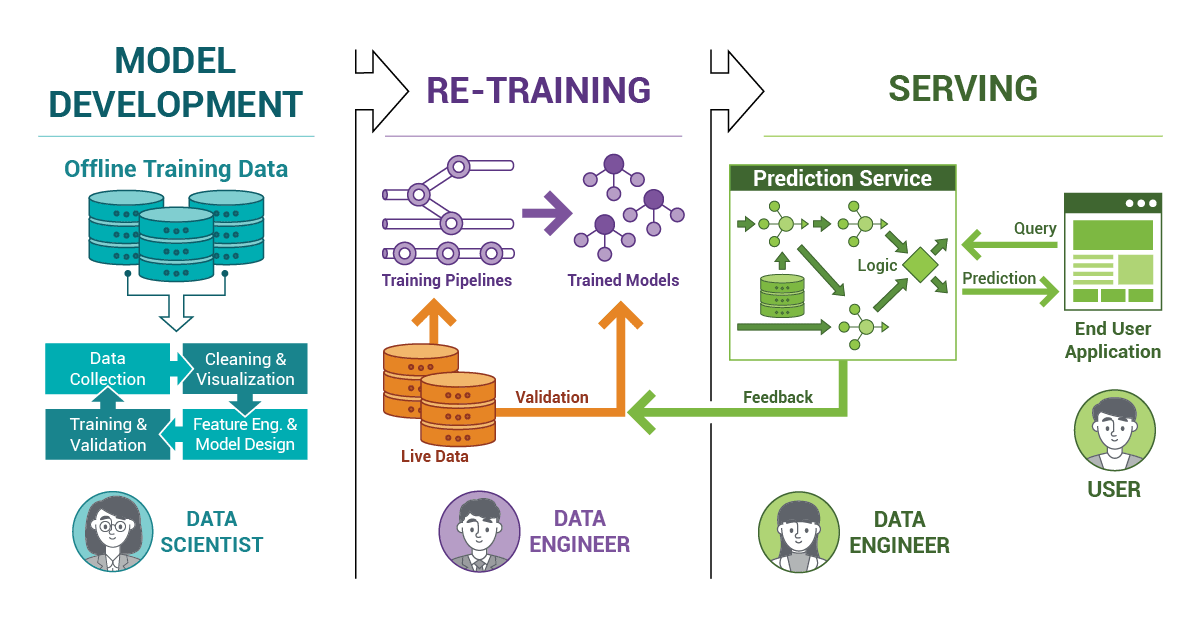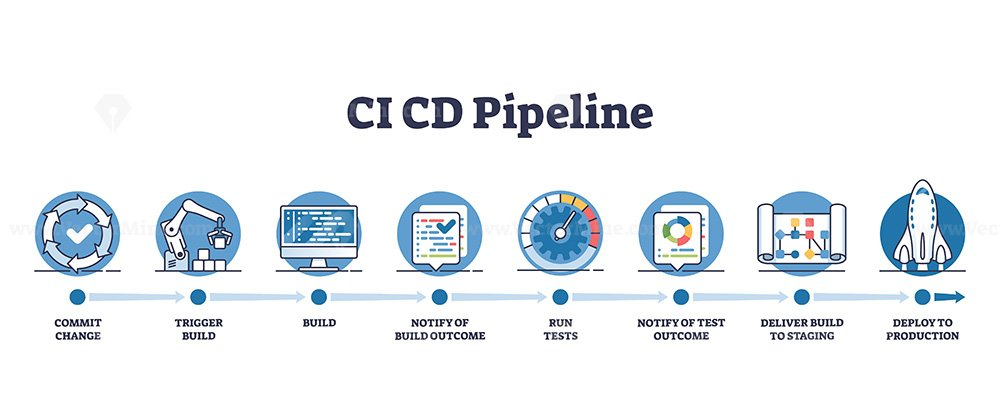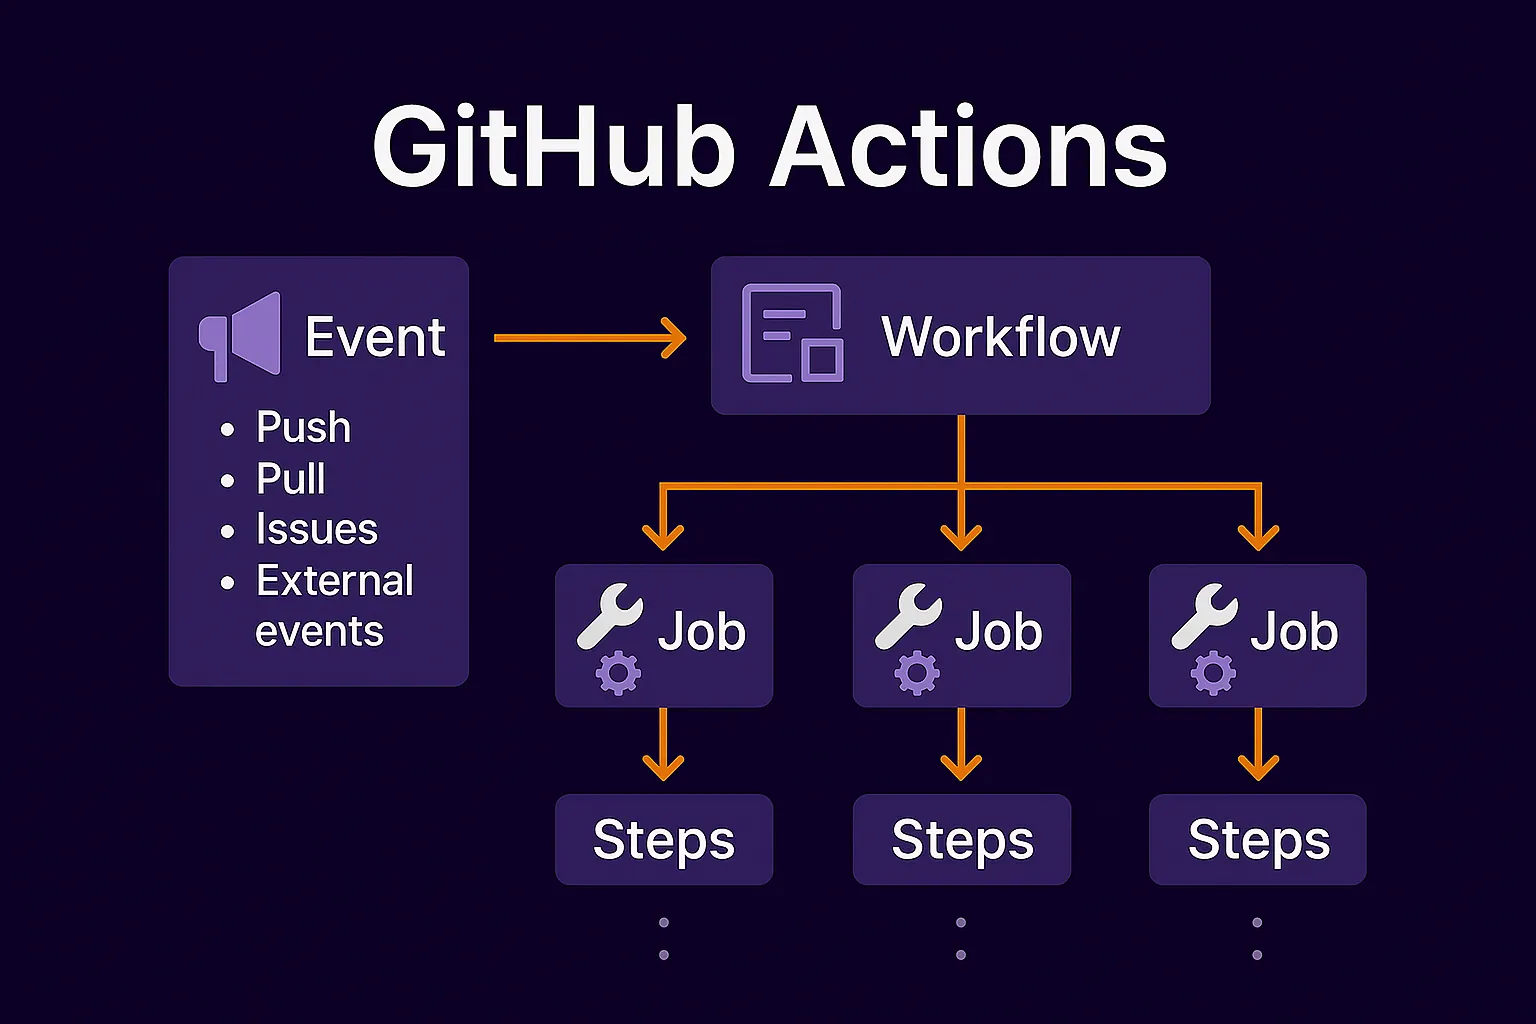

# **6.  Experience with container orchestration platforms (e.g., Kubernetes).**

   Kubernetes is widely used to orchestrate containers in production environments. For ML systems, it ensures:

  * Scalability: Handle multiple prediction requests efficiently.

  * Reliability: Automatic restarts and load balancing.

  * Automation: Rolling updates for new model versions.

  * Monitoring: Health checks and resource tracking.

# **⚙️ Example Kubernetes Workflow**
  **1. Dockerfile (Containerizing ML Model)**

In [ ]:
FROM python:3.9-slim

WORKDIR /app

COPY requirements.txt .
RUN pip install -r requirements.txt

COPY model.pkl .
COPY app.py .

CMD ["python", "app.py"]


**2. Kubernetes Deployment YAML**

In [ ]:
apiVersion: apps/v1
kind: Deployment
metadata:
  name: ml-model-deployment
spec:
  replicas: 3
  selector:
    matchLabels:
      app: ml-model
  template:
    metadata:
      labels:
        app: ml-model
    spec:
      containers:
      - name: ml-model-container
        image: myregistry/ml-model:latest
        ports:
        - containerPort: 5000
        resources:
          limits:
            cpu: "1"
            memory: "512Mi"
          requests:
            cpu: "0.5"
            memory: "256Mi"
        livenessProbe:
          httpGet:
            path: /health
            port: 5000
          initialDelaySeconds: 10
          periodSeconds: 30


**3. Kubernetes Service YAML**

In [ ]:
apiVersion: v1
kind: Service
metadata:
  name: ml-model-service
spec:
  selector:
    app: ml-model
  ports:
    - protocol: TCP
      port: 80
      targetPort: 5000
  type: LoadBalancer


  👉 This exposes the ML model as a RESTful API with load balancing across multiple pods.

# **🖼️ Kubernetes Architecture Visualization**

   Here’s a conceptual diagram of how Kubernetes orchestrates ML containers:

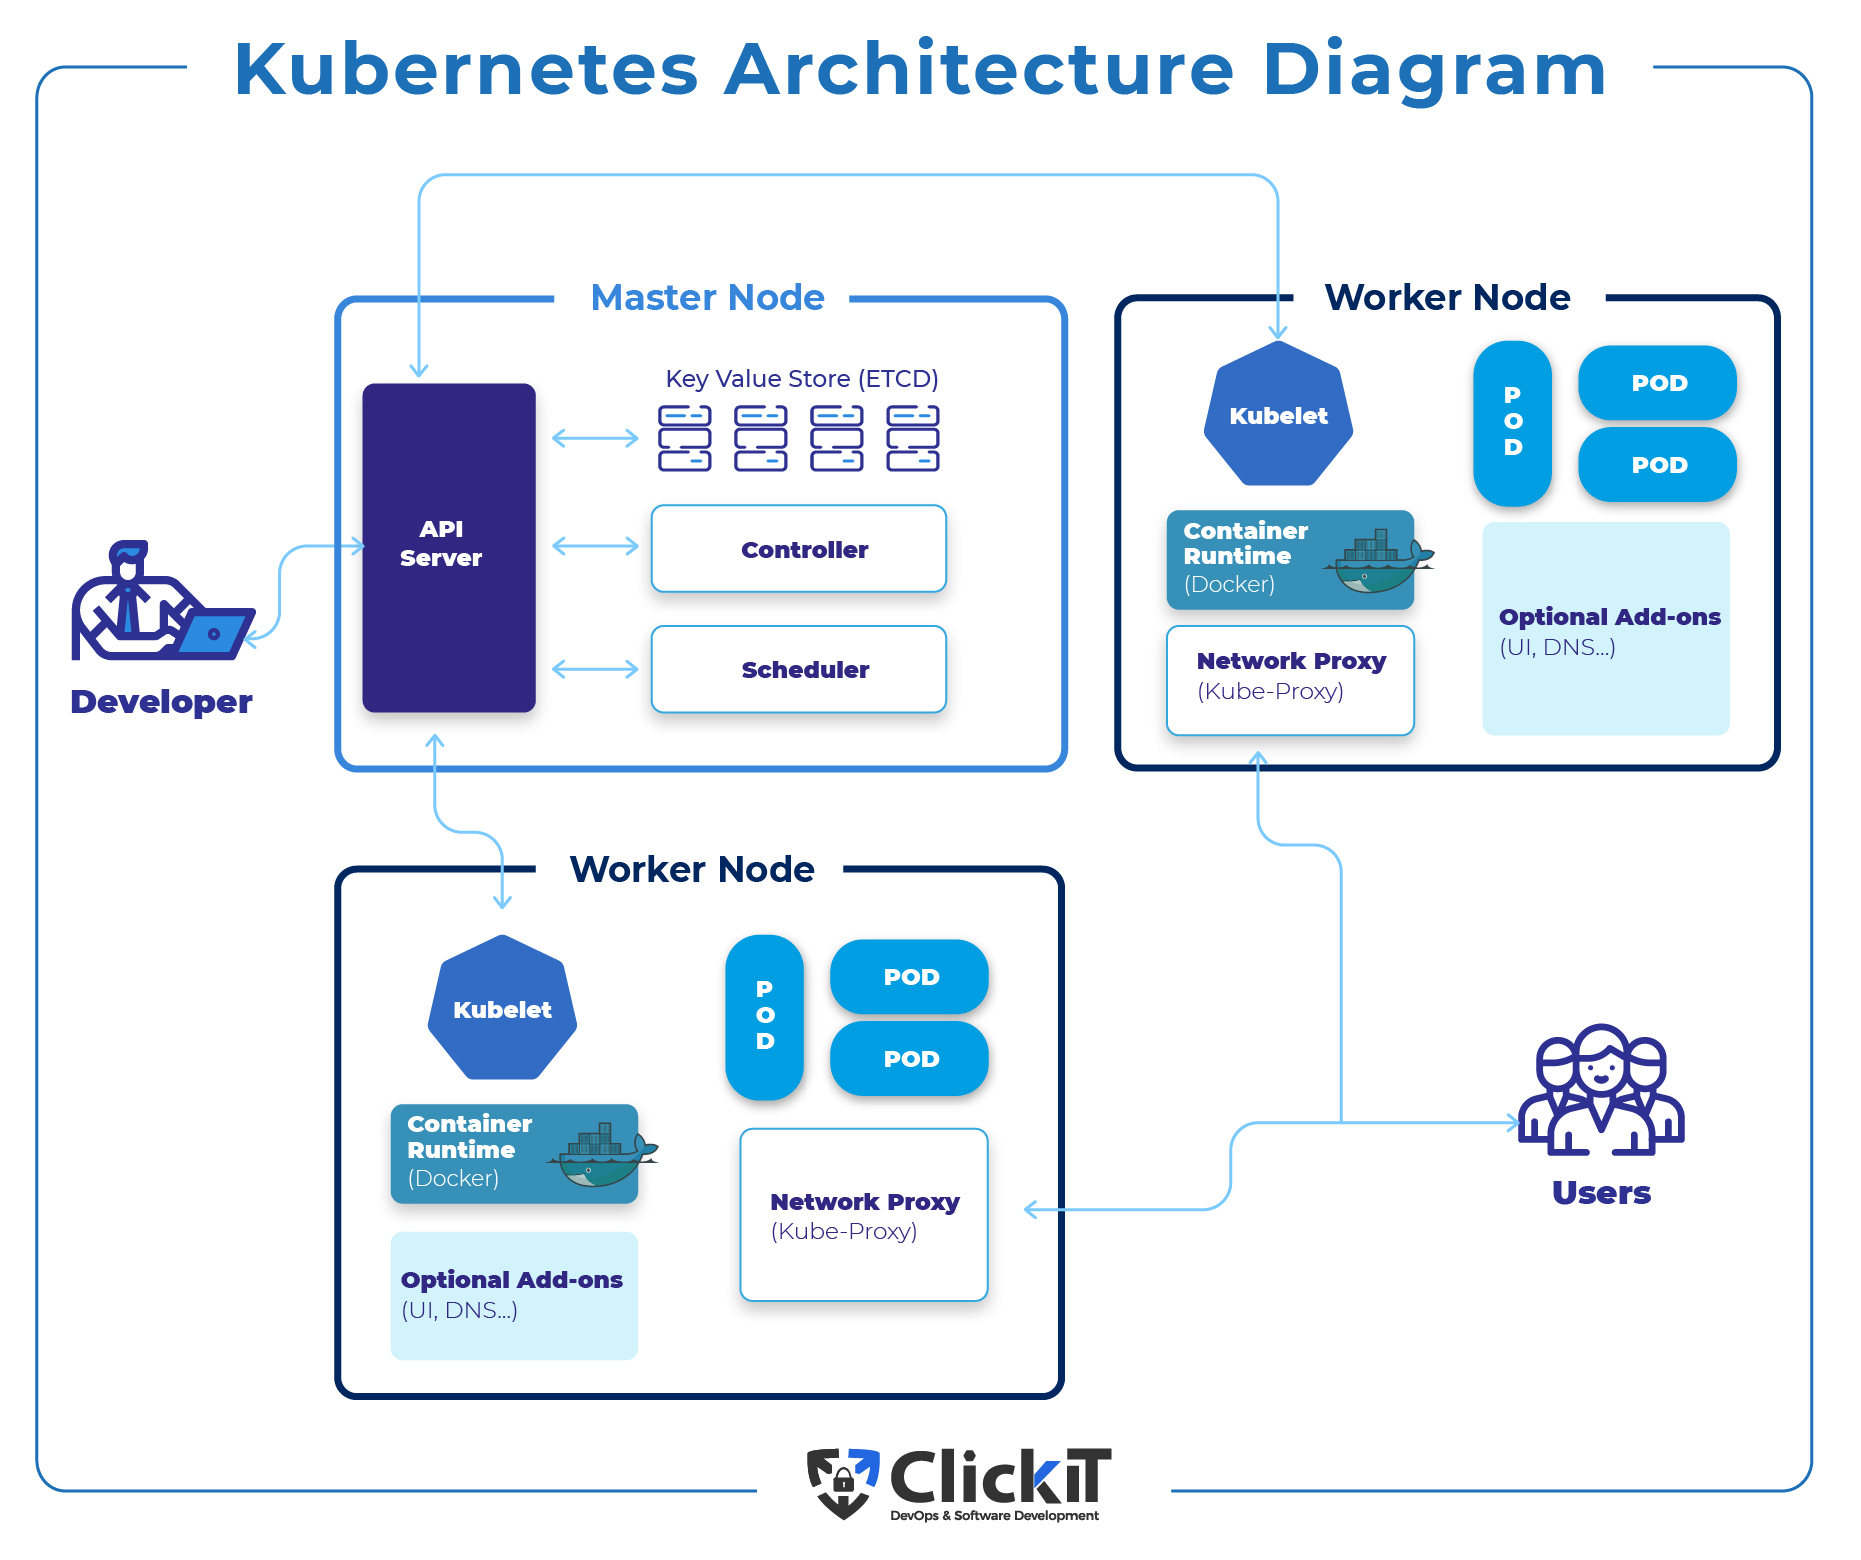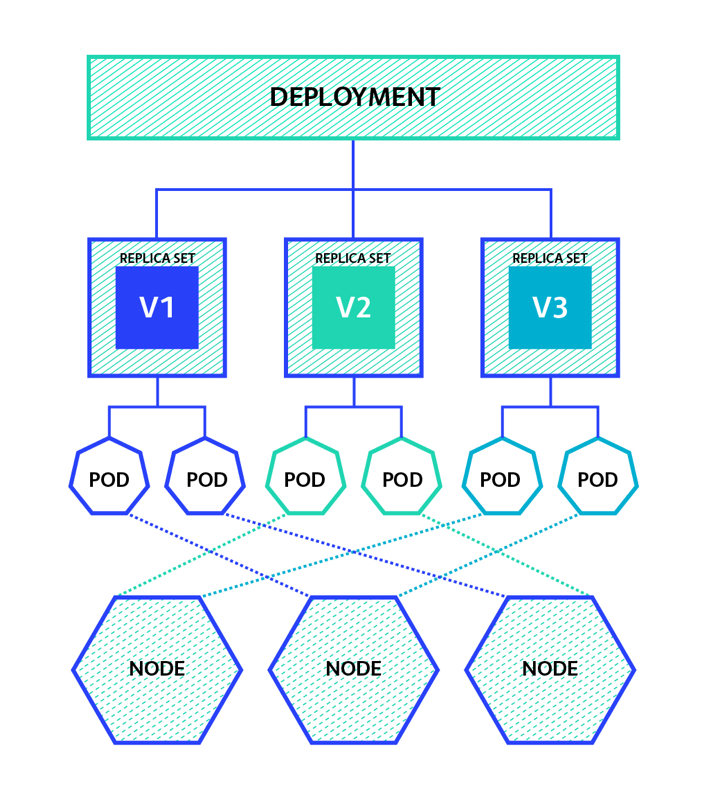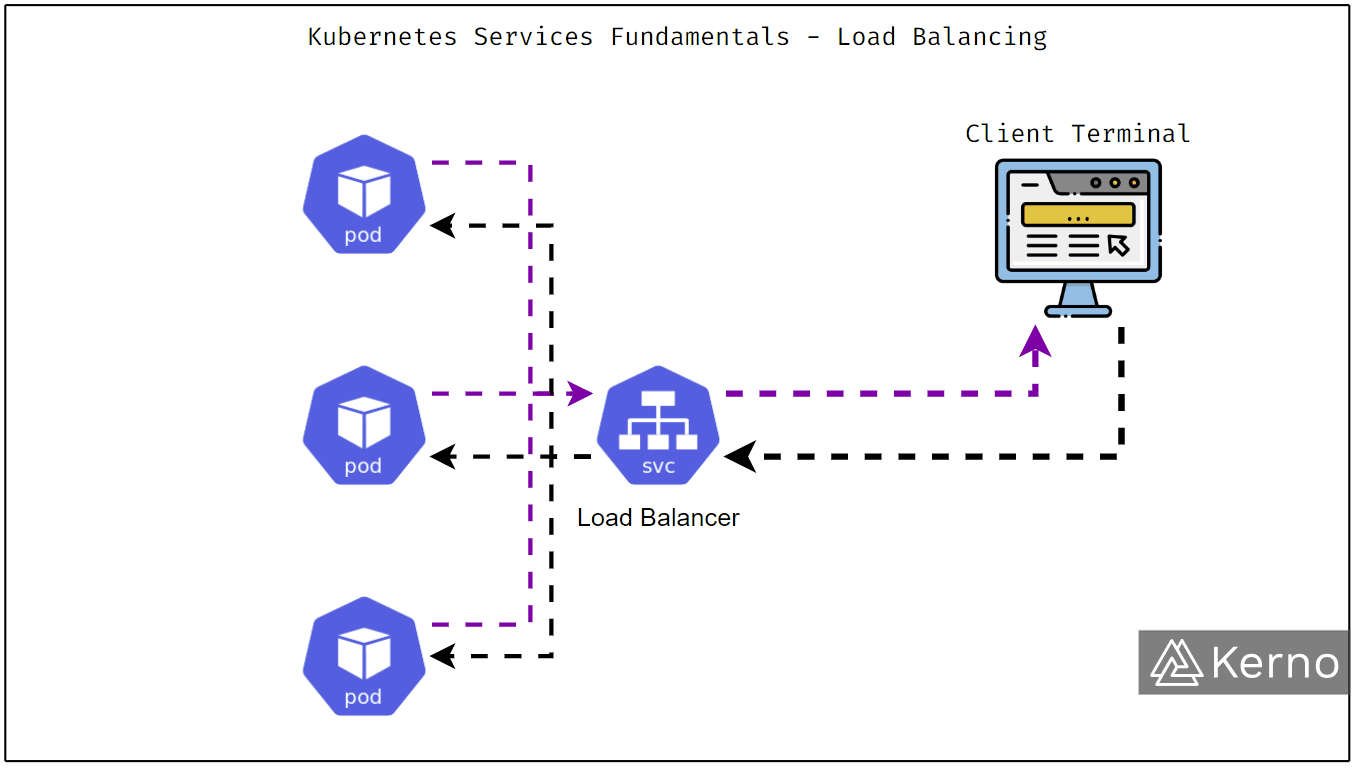

# **📈 Expected Outcomes**

   * Containerized ML models deployed on Kubernetes.

   * Scalable and reliable services with automatic failover.

   * Monitoring and health checks for production stability.

   * Seamless updates with rolling deployments.

  This demonstrates your hands-on experience with Kubernetes and how it fits into the productionization of ML systems.

  Would you like me to extend this into a real-world example using Minikube or Google Kubernetes Engine (GKE) so you can run the deployment locally or in the cloud?

# **7.  Strong understanding of model performance monitoring and troubleshooting.**

  Monitoring ML models in production is critical to ensure they continue performing well as data evolves. It involves:

  * Performance Metrics: Tracking accuracy, precision, recall, F1, MAE, etc.

  * Drift Detection: Identifying changes in data distribution.

  * Troubleshooting: Diagnosing issues like overfitting, underfitting, or degraded performance.

  * Alerts & Retraining: Triggering retraining when thresholds are crossed.

# **⚙️ Example Workflow with Code**
  
  **1. Performance Monitoring**

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# True vs predicted labels
y_true = [1, 0, 1, 1, 0, 1, 0]
y_pred = [1, 0, 1, 0, 0, 1, 1]

# Metrics
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")


  👉 These metrics can be logged into MLflow or monitoring dashboards.

**2. Drift Detection**

In [ ]:
import numpy as np

# Simulated old vs new feature distributions
old_mean, old_std = 50, 5
new_data = np.array([60, 62, 58, 65, 63])

# Simple drift check
if abs(new_data.mean() - old_mean) > old_std * 2:
    print("⚠️ Drift detected! Retraining required.")
else:
    print("✅ Model stable.")


  👉 Detects when new data distribution deviates significantly from training data.

**3. Troubleshooting Example**

In [ ]:
import matplotlib.pyplot as plt

# Example: plotting residuals for regression
y_true = np.array([100, 200, 300, 400, 500])
y_pred = np.array([110, 190, 310, 390, 480])

residuals = y_true - y_pred

plt.scatter(y_true, residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel("True Values")
plt.ylabel("Residuals")
plt.title("Residual Plot for Troubleshooting")
plt.show()


  👉 Residual plots help identify systematic errors (e.g., bias, underfitting).

# **🖼️ Monitoring Workflow Visualization**
Here’s a conceptual diagram of how monitoring fits into ML production:

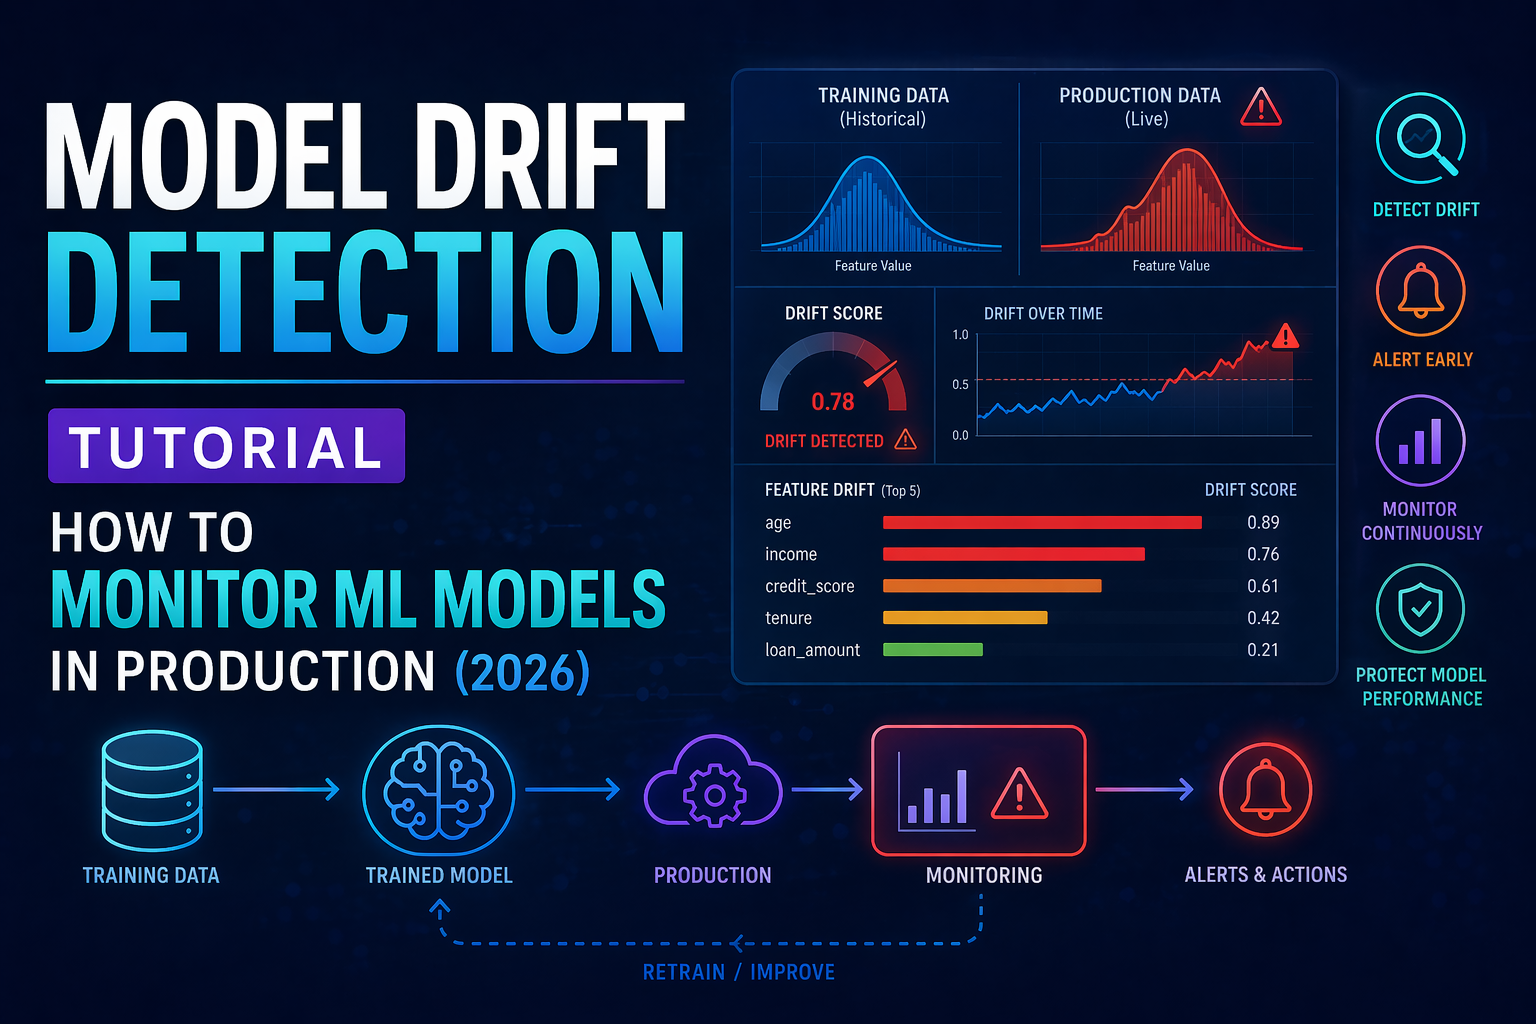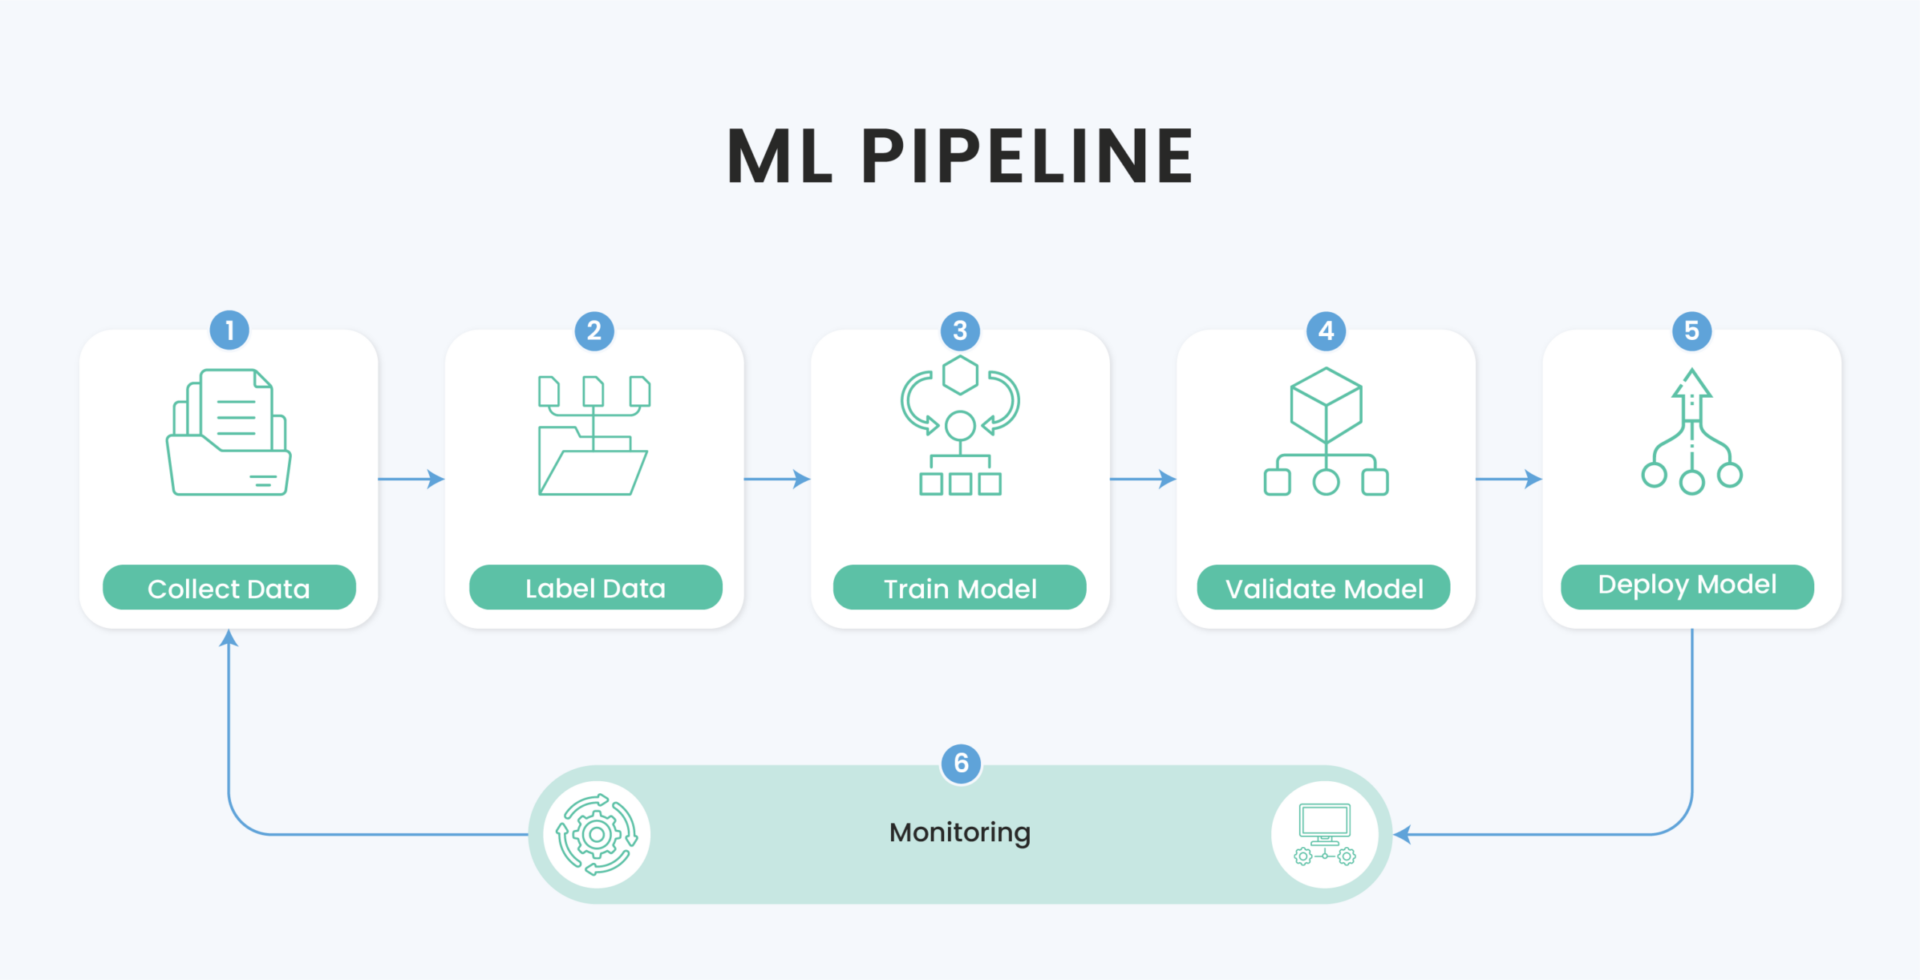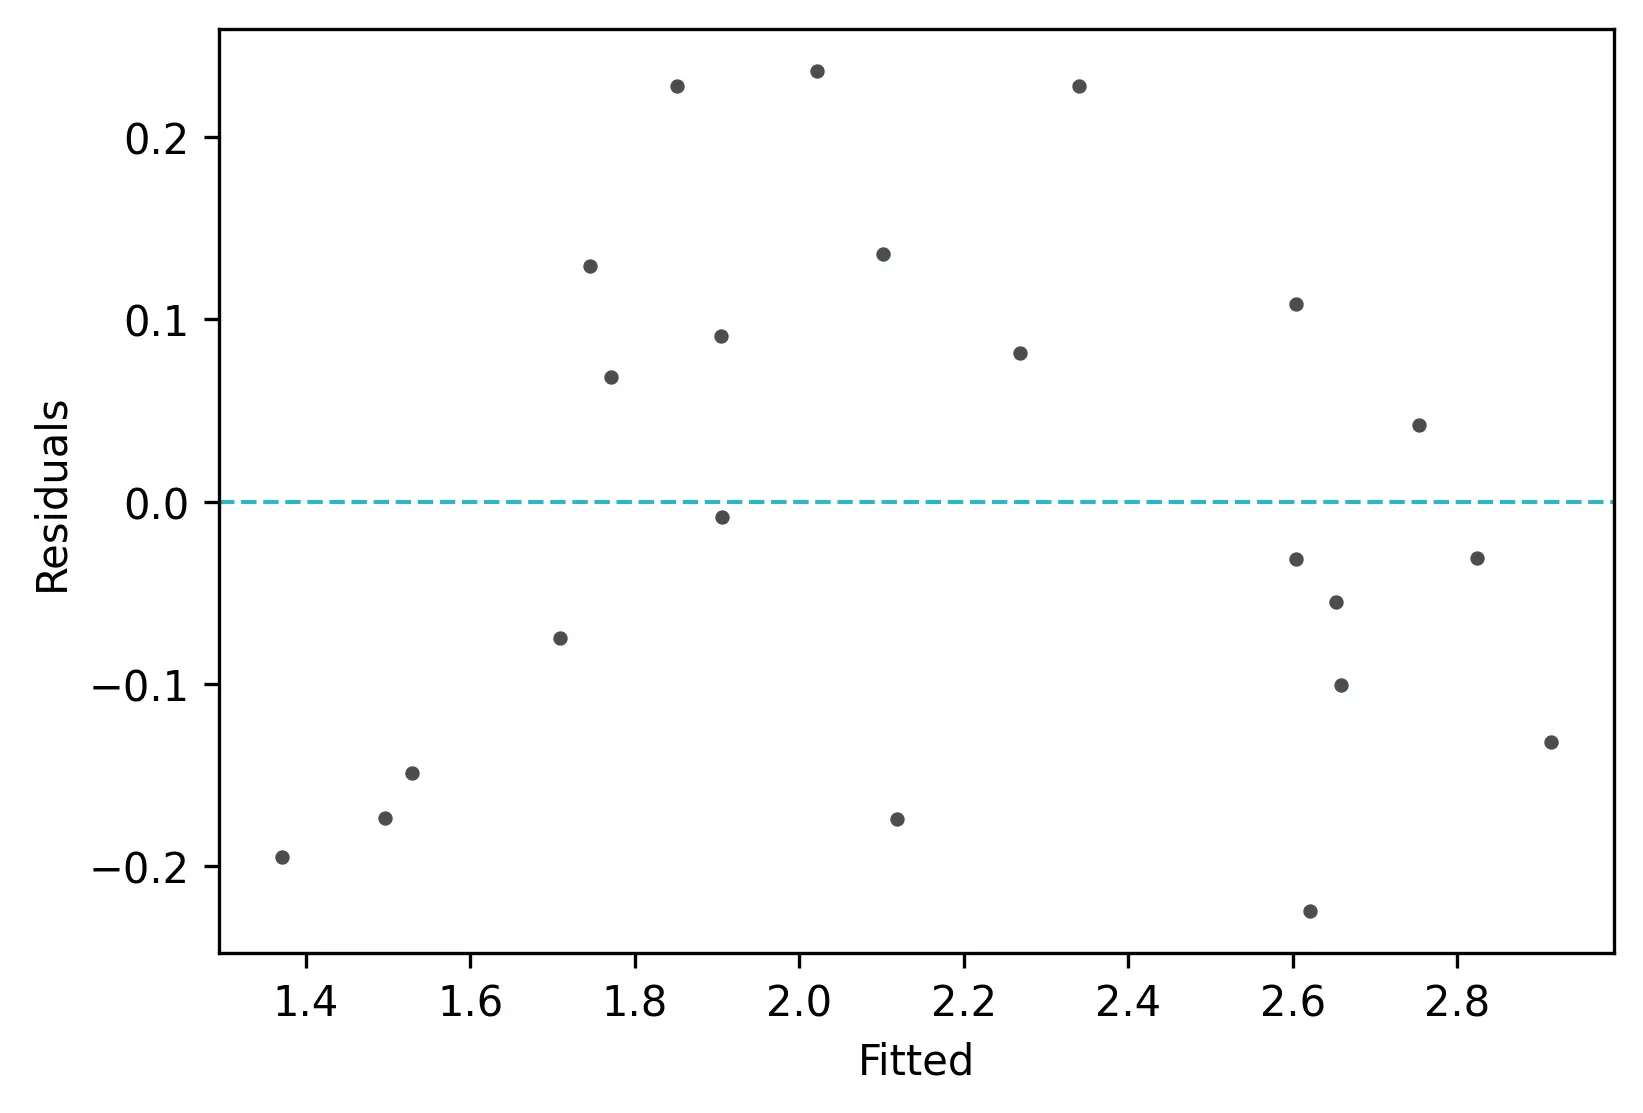

# **📈 Expected Outcomes**

  Continuous tracking of model performance metrics.

  * Early detection of data drift and degraded accuracy.

  * Visual troubleshooting tools for diagnosing issues.

  * Automated alerts and retraining pipelines to maintain reliability.

This demonstrates your hands-on expertise in monitoring and troubleshooting ML models — a crucial part of MLOps and productionization.

Would you like me to expand this into a Google Colab-ready notebook that integrates MLflow logging, drift detection, and troubleshooting plots so you can run the monitoring pipeline end-to-end?

# **Skills Demonstrated**

By completing this project, you will demonstrate:

* Data collection and preprocessing
* Exploratory Data Analysis (EDA)
* Feature engineering
* Machine learning model training
* Model evaluation and tuning
* Model serialization
* REST API development
* Docker containerization
* Git and GitHub workflow
* CI/CD automation
* Cloud deployment
* Model monitoring and maintenance

This type of capstone project showcases the complete machine learning lifecycle (MLOps) and is highly valued for Data Scientist and Machine Learning Engineer roles because it demonstrates not only model-building skills but also the ability to deploy and maintain models in production.

## **🧩 Important Notes**

  **Model Versioning:** Always maintain version control for models and datasets using tools like MLflow or DVC to ensure reproducibility and rollback capability.

  **CI/CD Integration:** Automate testing, retraining, and deployment pipelines through GitHub Actions or Jenkins for continuous improvement.

  **Monitoring & Logging:** Implement real-time monitoring for model drift, latency, and prediction accuracy using Prometheus, Grafana, or EvidentlyAI.

  **Scalability:** Use container orchestration (Kubernetes, Docker Swarm) to handle high traffic and parallel inference efficiently.

  **Security & Compliance:** Ensure data privacy, encryption, and compliance with standards like GDPR when handling user data.

  **Cross-functional Collaboration:** Work closely with data engineers, DevOps, and business teams to align ML outcomes with organizational goals.

  **Documentation:** Maintain clear documentation for APIs, data schemas, and deployment workflows to support maintainability and scalability.

## **🚀 Final Takeaway**
  
  Productionization transforms ML models from prototypes into robust, scalable, and monitored services. It’s the bridge between data science experimentation and real-world engineering, showcasing your ability to deliver end-to-end MLOps solutions.